YOLOv5 🚀 2026-9-1 Python-3.13.15 torch-2.11.0+cpu CPU

Fusing layers... 


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master


Model summary: 68 layers, 7,018,216 parameters, 0 gradients
Adding AutoShape... 


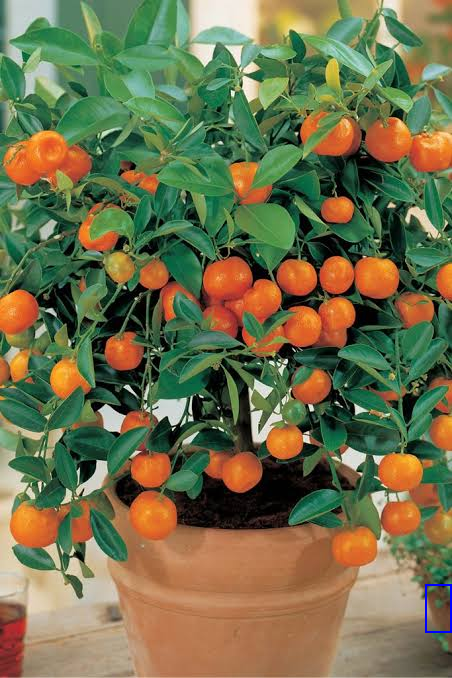

         xmin        ymin        xmax        ymax  confidence  class    name
0  425.975647  584.274414  451.918549  632.929382    0.434596      2  tomato


In [31]:
import torch
import cv2
from PIL import Image, ImageDraw, ImageFont

# Install yolov5 package as it contains the ultralytics module
!pip install yolov5 # If it installed in the previous run, no need to run again.

# 1. Load your custom trained YOLOv5 model
# Note: 'custom' tells PyTorch Hub to load a local weight file instead of a pretrained model
model = torch.hub.load('ultralytics/yolov5', 'custom', path=r'/content/best.pt')

# 2. Define the path to your single image
image_path = r'/content/image.jpg'

# 3. Run inference
results = model(image_path)

# 4. Process and show results with conditional labeling
# Get detection data as a pandas DataFrame
detections_df = results.pandas().xyxy[0]

# Load the image using PIL to draw on it
img = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(img)

# Define font for labels (adjust path/name as needed, or use a default)
try:
    font = ImageFont.truetype("arial.ttf", 15)
except IOError:
    font = ImageFont.load_default()

# Set confidence threshold
CONFIDENCE_THRESHOLD = 0.50

# Iterate through each detection
for *xyxy, conf, cls, name in detections_df.values:
    x1, y1, x2, y2 = map(int, xyxy)
    confidence = float(conf)

    # Draw bounding box (blue color for example)
    draw.rectangle([x1, y1, x2, y2], outline="blue", width=2)

    # Only add label if confidence is above the threshold
    if confidence >= CONFIDENCE_THRESHOLD:
        label = f"{name} {confidence:.2f}"
        draw.text((x1, y1 - 15), label, fill="blue", font=font)

# Display the modified image
# In Colab, you can display PIL images directly
display(img)

# 5. Optional: Print the raw coordinates and labels to the console
# results.pandas().xyxy[0] returns a Pandas DataFrame with xmin, ymin, xmax, ymax, confidence, class, name
print(detections_df)
